# Field debug — azimuth sensors (motor / potmon / IMU)

Quick triage of the azimuth chain. Works on either:
- a recorder metadata file (`metadata_*.h5`), or
- a correlation file (`*.h5`) with metadata in its `metadata` group.

**Usage:** set `FILE` below (or leave `""` to auto-pick the newest `*.h5`
nearby), then Run All. Plots motor `az_pos`/`az_target_pos`, potmon
(angle if calibrated, else raw voltage), and imu_az `yaw`/`pitch`/`roll`
versus time.

In [1]:
# EDIT: path to a metadata_*.h5 or corr *.h5 file. "" = auto-pick newest *.h5.
FILE = ""

from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from eigsep_observing.io import read_hdf5, read_metadata_hdf5

if FILE:
    path = Path(FILE).expanduser()
else:
    here = Path.cwd()
    cands = [p for d in [here, *here.parents] for p in d.glob("*.h5")]
    assert cands, "no *.h5 found nearby; set FILE explicitly"
    path = max(cands, key=lambda p: p.stat().st_mtime)
assert path.exists(), f"file not found: {path}"
print("loading", path)

loading /home/christian/Documents/research/eigsep/eigsep_observing/metadata_20260627_174241.h5


In [2]:
def load_streams(path):
    """Return (streams, times_s, kind).

    streams: {name: [sample_dict|None, ...]}
    times_s: {name: np.ndarray} seconds since file start, index-aligned to
             the dict list (NaN where a sample has no timestamp).
    kind:    'corr' or 'metadata'.

    corr files have no per-sample timestamp (metadata is averaged per
    integration), so time = integration_index * integration_time. recorder
    files carry a per-sample `_ts_unix`.
    """
    with h5py.File(path, "r") as f:
        is_corr = "data" in f and "header" in f
    if is_corr:
        _, header, md = read_hdf5(path)
        dt = float(header.get("integration_time", 1.0))
        streams = {k: v for k, v in md.items() if isinstance(v, list)}
        times = {k: np.arange(len(v)) * dt for k, v in streams.items()}
        return streams, times, "corr"
    streams = read_metadata_hdf5(path)
    stamps = [
        s["_ts_unix"]
        for v in streams.values()
        for s in v
        if s is not None and "_ts_unix" in s
    ]
    t0 = min(stamps) if stamps else 0.0
    times = {
        k: np.array([
            (s["_ts_unix"] - t0)
            if (s is not None and "_ts_unix" in s)
            else np.nan
            for s in v
        ])
        for k, v in streams.items()
    }
    return streams, times, "metadata"


streams, times, kind = load_streams(path)


def series(stream, field):
    """(t_sec, values) for one field; drops None/error/NaN-time samples."""
    if stream not in streams:
        return np.array([]), np.array([])
    t, y = [], []
    for ti, s in zip(times[stream], streams[stream]):
        if s is None or s.get("status") == "error" or np.isnan(ti):
            continue
        val = s.get(field)
        if val is None:
            continue
        t.append(ti)
        y.append(val)
    return np.array(t), np.array(y)


# Summary: which streams are present, sample counts, status breakdown.
print(f"file kind: {kind}\n")
for k in ["motor", "potmon", "imu_az"]:
    if k not in streams:
        print(f"{k:8s} : NOT PRESENT")
        continue
    good = [s for s in streams[k] if s is not None and s.get("status") != "error"]
    err = [s for s in streams[k] if s is not None and s.get("status") == "error"]
    print(f"{k:8s} : {len(streams[k]):4d} samples  ({len(good)} ok, {len(err)} error)")

file kind: metadata

motor    :  317 samples  (317 ok, 0 error)
potmon   :  356 samples  (356 ok, 0 error)
imu_az   :  355 samples  (355 ok, 0 error)


saved /home/christian/Documents/research/eigsep/eigsep_observing/notebooks/field_debug/az_sensors_metadata_20260627_174241.png


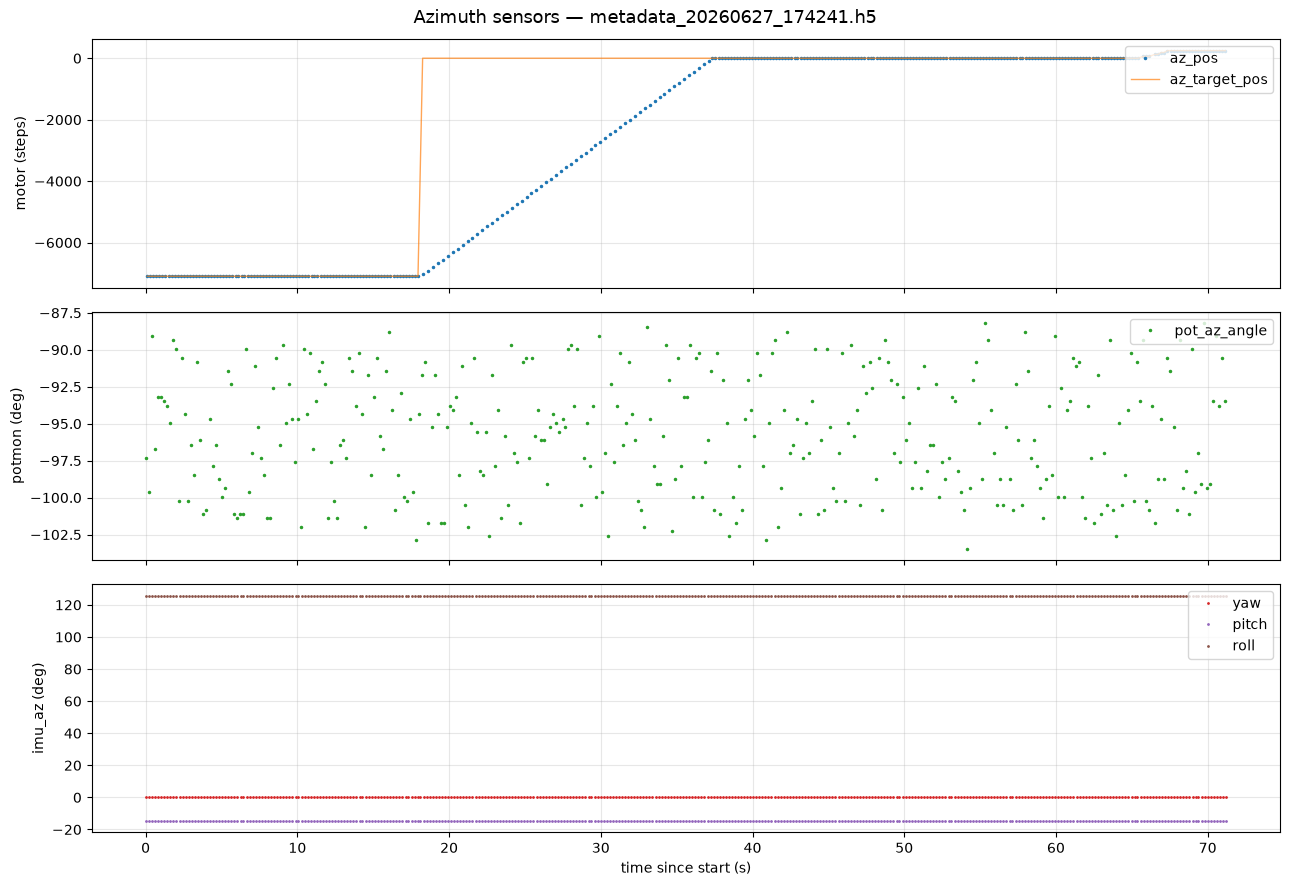

In [3]:
xlabel = (
    "time since start (s)"
    if kind == "metadata"
    else "time (s) = integration \u00d7 integration_time"
)
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)


def empty_note(ax, msg):
    ax.text(0.5, 0.5, msg, transform=ax.transAxes, ha="center", va="center",
            color="gray")


# --- motor (steps) ---
t, y = series("motor", "az_pos")
if len(t):
    axes[0].plot(t, y, ".", ms=3, label="az_pos")
    t2, y2 = series("motor", "az_target_pos")
    if len(t2):
        axes[0].plot(t2, y2, "-", lw=1, alpha=0.7, label="az_target_pos")
    axes[0].legend(loc="upper right")
else:
    empty_note(axes[0], "no motor data")
axes[0].set_ylabel("motor (steps)")
axes[0].grid(alpha=0.3)

# --- potmon: prefer calibrated angle, fall back to raw voltage ---
t, y = series("potmon", "pot_az_angle")
if len(t):
    axes[1].plot(t, y, ".", ms=3, color="tab:green", label="pot_az_angle")
    axes[1].set_ylabel("potmon (deg)")
else:
    t, y = series("potmon", "pot_az_voltage")
    if len(t):
        axes[1].plot(t, y, ".", ms=3, color="tab:green", label="pot_az_voltage (uncal)")
    else:
        empty_note(axes[1], "no potmon data")
    axes[1].set_ylabel("potmon (V)")
if axes[1].get_legend_handles_labels()[0]:
    axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

# --- imu_az (deg) ---
any_imu = False
for field, color in [("yaw", "tab:red"), ("pitch", "tab:purple"), ("roll", "tab:brown")]:
    t, y = series("imu_az", field)
    if len(t):
        any_imu = True
        axes[2].plot(t, y, ".", ms=2, color=color, label=field)
if any_imu:
    axes[2].legend(loc="upper right")
else:
    empty_note(axes[2], "no imu_az data")
axes[2].set_ylabel("imu_az (deg)")
axes[2].set_xlabel(xlabel)
axes[2].grid(alpha=0.3)

fig.suptitle(f"Azimuth sensors \u2014 {path.name}", fontsize=13)
fig.tight_layout()
out = Path.cwd() / f"az_sensors_{path.stem}.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)